In [45]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

In [2]:
df = pd.read_csv('beijing_dataset.csv')

In [7]:
pd.set_option('display.max_columns', None)

In [8]:
df.head()

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
0,1,2010,1,1,0,NaN,-21,-11.0,1021.0,NW,1.79,0,0
1,2,2010,1,1,1,NaN,-21,-12.0,1020.0,NW,4.92,0,0
2,3,2010,1,1,2,NaN,-21,-11.0,1019.0,NW,6.71,0,0
3,4,2010,1,1,3,NaN,-21,-14.0,1019.0,NW,9.84,0,0
4,5,2010,1,1,4,NaN,-20,-12.0,1018.0,NW,12.97,0,0


In [36]:
df.drop(columns='No', inplace=True)

In [10]:
df.isnull().sum()

No          0
year        0
month       0
day         0
hour        0
pm2.5    2067
DEWP        0
TEMP        0
PRES        0
cbwd        0
Iws         0
Is          0
Ir          0
dtype: int64

In [11]:
df.describe()

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,Iws,Is,Ir
count,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,41757.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000
mean,21912.500000,2012.000000,6.523549,15.727820,11.500000,98.613215,1.817246,12.448521,1016.447654,23.889140,0.052734,0.194916
std,12651.043435,1.413842,3.448572,8.799425,6.922266,92.050387,14.433440,12.198613,10.268698,50.010635,0.760375,1.415867
min,1.000000,2010.000000,1.000000,1.000000,0.000000,0.000000,-40.000000,-19.000000,991.000000,0.450000,0.000000,0.000000
25%,10956.750000,2011.000000,4.000000,8.000000,5.750000,29.000000,-10.000000,2.000000,1008.000000,1.790000,0.000000,0.000000
50%,21912.500000,2012.000000,7.000000,16.000000,11.500000,72.000000,2.000000,14.000000,1016.000000,5.370000,0.000000,0.000000
75%,32868.250000,2013.000000,10.000000,23.000000,17.250000,137.000000,15.000000,23.000000,1025.000000,21.910000,0.000000,0.000000
max,43824.000000,2014.000000,12.000000,31.000000,23.000000,994.000000,28.000000,42.000000,1046.000000,585.600000,27.000000,36.000000


In [40]:
df.dropna(subset=['pm2.5'], inplace=True)

In [41]:
df['cbwd'].value_counts()

cbwd
SE    14573
NW    13484
cv     8944
NE     4756
Name: count, dtype: int64

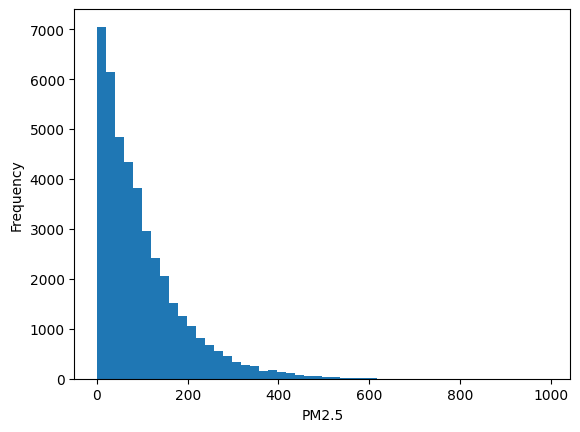

In [19]:
plt.hist(df['pm2.5'], bins=50)
plt.xlabel('PM2.5')
plt.ylabel('Frequency')
plt.show()

<Axes: ylabel='pm2.5'>

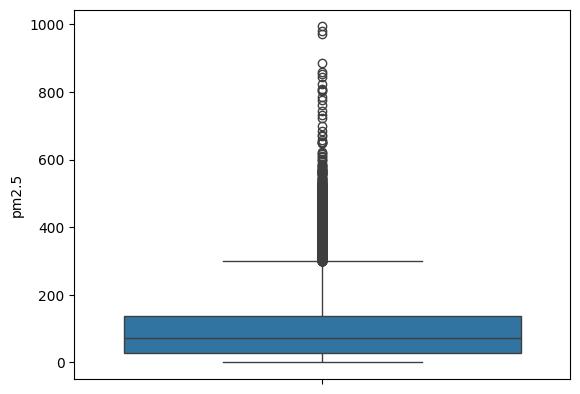

In [23]:
sns.boxplot(df['pm2.5'])

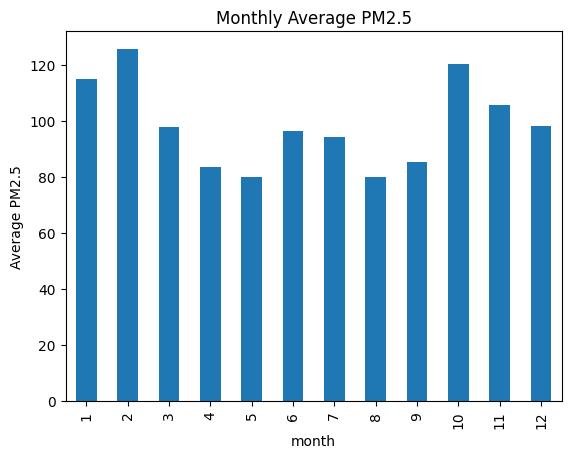

In [24]:
monthly_pm = df.groupby('month')['pm2.5'].mean()

monthly_pm.plot(kind='bar')
plt.ylabel('Average PM2.5')
plt.title('Monthly Average PM2.5')
plt.show()

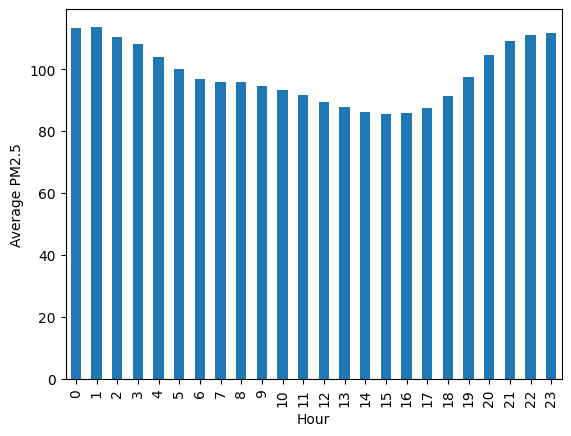

In [25]:
hourly_pm = df.groupby('hour')['pm2.5'].mean()

hourly_pm.plot(kind='bar')
plt.xlabel('Hour')
plt.ylabel('Average PM2.5')
plt.show()

<Axes: xlabel='cbwd', ylabel='pm2.5'>

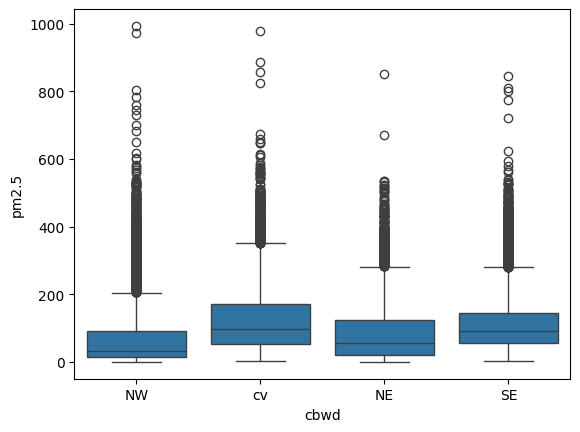

In [27]:
sns.boxplot(x=df['cbwd'], y=df['pm2.5'], data=df)

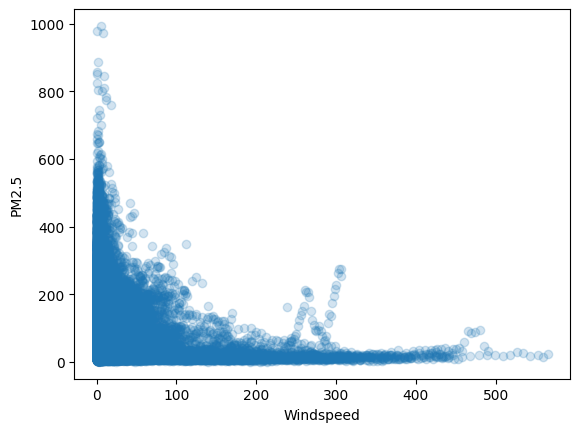

In [29]:
plt.scatter(df['Iws'], df['pm2.5'], alpha=0.2)
plt.xlabel('Windspeed')
plt.ylabel('PM2.5')
plt.show()

In [43]:
X = df.drop('pm2.5', axis=1)
y = df['pm2.5']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [44]:
numerical_cols = X_train.select_dtypes(include=['float64', 'int64']).columns.to_list()

In [ ]:
numerical_pipeline = Pipeline(steps=[
    (numerical_cols, RobustScaler())
])

categorical_pipeline = Pipeline(steps=[
    ()
])